# Survival Analysis: Time to Defibrillation vs. Patient Outcomes (Unbinned Logistic Regression)

This notebook analyzes the Out-of-Hospital Cardiac Arrest (OHCA) dataset to quantify how delay to first defibrillation affects patient outcomes.

Specifically, it uses **unbinned patient-level data** (one row per patient), computes **Time to First Defibrillation** from dispatch-call and first-shock timestamps, and fits two **logistic regression models** (`statsmodels.Logit`) over a constrained 0–20 minute window:

- **Predictor (X):** Time to First Defibrillation (minutes)
- **Outcome 1 (y):** Survival Status (1 = Survived, 0 = Dead)
- **Outcome 2 (y):** CPC Status (1 = Good CPC 1–2, 0 = Poor CPC 3–5)

Key outputs include:

- Logistic regression coefficient estimates, p-values, and model summaries
- **Odds Ratio** interpretation for each 1-minute delay (Survival and CPC)
- Fitted probability curves for Survival and CPC across 0–20 minutes
- A combined visualization comparing both modeled outcome curves

This provides a standard epidemiological estimate of the time–outcome relationship without time binning or exponential curve fitting.

# Need to install decryption Libraries

In [1]:
%pip install msoffcrypto-tool openpyxl

Note: you may need to restart the kernel to use updated packages.


# Install libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import msoffcrypto
import io
import openpyxl
import statsmodels.api as sm

from pathlib import Path

# Get the password from env

In [3]:
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [4]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = CURRENT_DIRECTORY.parents[0] / "datasets"
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"

display(ENCRYPTED_FILE_PATH)


PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [5]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    # display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/opt/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


In [13]:
print(df.columns.tolist())


['Case #', 'Country', 'City', 'Site #', 'Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Medical History - No', 'Medical History - Unknown', 'Medical History - Heart disease', 'Medical History - Diabetes', 'Medical History - Cancer', 'Medical History - Hypertension', 'Medical History - Renal Disease', 'Medical History - Respiratory Disease', 'Medical History - Hyperlipidemia', 'Medical History - Stroke', 'Medical History - HIV', 'Medical History - Other', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance left scene', 'Time Ambulance arrived at ED', 'Estimated time of arrest', 'Estimated time of arrest unknown', 'Arrest witnessed by', 'Bystander CPR', 'DA

# Setting columns for feature engineering

In [6]:
# This will be used to calculate time to defib
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'

# This will be used to calculate into a binary status of 0/1 survival
status_col = 'Patient status'

# This will be used for CPC analysis
cpc_col = 'Patient neurological status - Cerebral'

df_survival = df.copy()
# display(df_survival[[call_time_col, shock_time_col, status_col, cpc_col]].head())

# Calculating the time to defib

In [7]:
df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
                                          format = "mixed",
                                          errors='coerce')
df_survival['Shock_Time'] = pd.to_datetime(df_survival[shock_time_col].astype(str),
                                           format='mixed',
                                           errors='coerce')

# Calculate the difference in minutes
df_survival['Time_to_Defib'] = (df_survival['Shock_Time'] - df_survival['Call_Time']).dt.total_seconds() / 60

# Fix midnight crossover overlaps
df_survival.loc[df_survival['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440

# display(df_survival[['Call_Time', 'Shock_Time', 'Time_to_Defib']].head(10))

Time to defib will show 13.9 minutes (standard decimal format)

Example (Index 0):
-   54 seconds ÷ 60 seconds = 0.90 minutes.
-   13 minutes + 0.90 minutes = 13.90 minutes.

# Feature Engineering for Survival Status

- 0 = Dead
- 1 = Survived

In [8]:
df_survival['Survival_Status'] = ~df_survival[status_col].astype(str).str.contains('Dead|Died',
                                                                                   case=False,
                                                                                   na=False)
df_survival['Survival_Status'] = df_survival['Survival_Status'].astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status']].head())

# Feature Engineering for CPC Status

-   1 = Good (CPS 1-2)
-   0 = Bad (CPC 3-5)

In [9]:
df_survival['CPC_Status'] = df_survival[cpc_col].astype(str).str.contains('1|2',
                                                                          regex=True).astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status', 'CPC_Status']].head(10))

# Creating a clean dataframe for analysis

In [10]:
df_clean = df_survival.dropna(subset=["Time_to_Defib", "Survival_Status", "CPC_Status"]).copy()

time_col = 'Time_to_Defib'
surv_col = 'Survival_Status'

#  Time cannot be negative, max out at 20 mins
df_log = df_clean[(df_clean[time_col] >= 0) & (df_clean[time_col] <= 20)].copy()

# Define X (independent variable) and y (dependent variable)

In [11]:
X_log = df_log[time_col]

# This adds the y-intercept term to the model (the constant term)
X_log = sm.add_constant(X_log)
y_log = df_log[surv_col]



# Fitting the Logistic Regression Model

In [12]:
logit_model = sm.Logit(y_log, X_log)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.446708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        Survival_Status   No. Observations:                 3823
Model:                          Logit   Df Residuals:                     3821
Method:                           MLE   Df Model:                            1
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.01025
Time:                        20:24:25   Log-Likelihood:                -1707.8
converged:                       True   LL-Null:                       -1725.4
Covariance Type:            nonrobust   LLR p-value:                 2.746e-09
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.6216      0.168      3.692      0.000       0.292       0.952
Time_to_Defib     0.

# Calculate the Odds Ratio for 1-minute delay

In [22]:
odds_ratio = np.exp(result.params[time_col])
print(f"\nOdds Ratio for 1-min delay: {odds_ratio:.4f}")
print(f"Every 1 minute delay decreases the odds of a good survival outcome by {((1 - odds_ratio) * 100):.2f} %.")


Odds Ratio for 1-min delay: 1.0780
Every 1 minute delay decreases the odds of a good survival outcome by -7.80 %.


# Plotting the LR Curve against the data

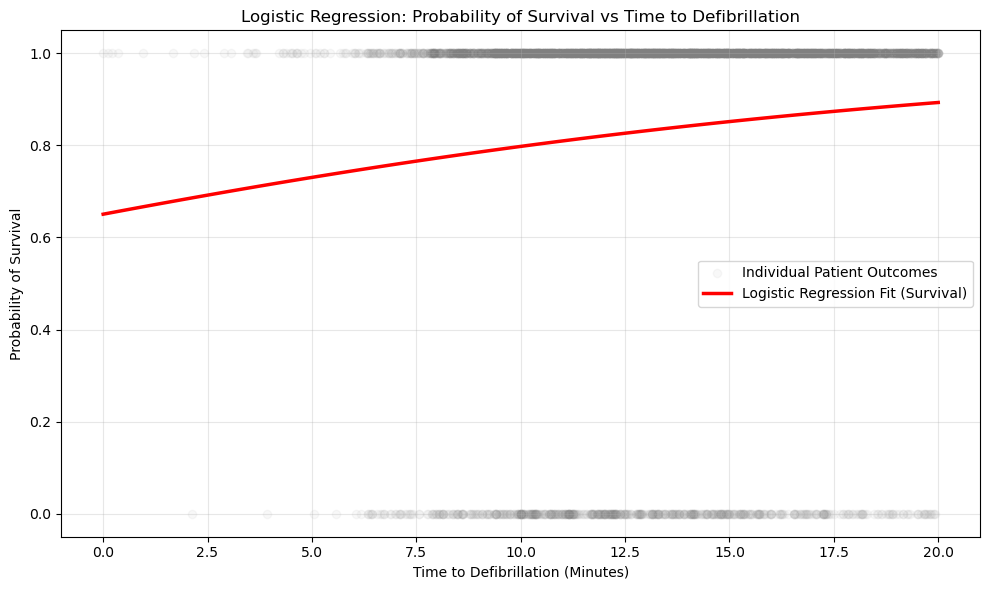

In [14]:
t_range = np.linspace(0, 20, 100)
X_pred = sm.add_constant(t_range)
y_pred_prob = result.predict(X_pred)

plt.figure(figsize=(10, 6))
# Actual unbinned patient outcomes as transparent dots (0 = Dead, 1 = Survived)
plt.scatter(df_log[time_col],
            df_log[surv_col],
            alpha=0.05,
            color='gray',
            label='Individual Patient Outcomes')

# Plot the Logistic probability curve
plt.plot(t_range,
         y_pred_prob,
         color='red',
         linewidth=2.5,
         label='Logistic Regression Fit (Survival)')

plt.title('Logistic Regression: Probability of Survival vs Time to Defibrillation')
plt.xlabel('Time to Defibrillation (Minutes)')
plt.ylabel('Probability of Survival')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Fitting Logistic Regression to CPC

In [15]:
y_cpc = df_log['CPC_Status'] 

# Fit the Logistic Regression Model for CPC using the existing X_log
logit_model_cpc = sm.Logit(y_cpc, X_log)
result_cpc = logit_model_cpc.fit()

# Print the statistical summary for CPC(1-2 vs 3-5)
print(result_cpc.summary())

Optimization terminated successfully.
         Current function value: 0.305888
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             CPC_Status   No. Observations:                 3823
Model:                          Logit   Df Residuals:                     3821
Method:                           MLE   Df Model:                            1
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.01982
Time:                        20:24:25   Log-Likelihood:                -1169.4
converged:                       True   LL-Null:                       -1193.1
Covariance Type:            nonrobust   LLR p-value:                 6.097e-12
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.8361      0.208     -4.013      0.000      -1.244      -0.428
Time_to_Defib    -0.

# Calculate the Odds Ratio for 1-minute delay on Neurological Outcome

In [21]:
odds_ratio_cpc = np.exp(result_cpc.params[time_col])
print(f"\nOdds Ratio for 1-min delay (CPC): {odds_ratio_cpc:.4f}")
print(f"Every 1 minute delay decreases the odds of a good neurological outcome by {((1 - odds_ratio_cpc) * 100):.2f} %.")


Odds Ratio for 1-min delay (CPC): 0.8950
Every 1 minute delay decreases the odds of a good neurological outcome by 10.50 %.


# Plotting both Logistic Regression Curves Together

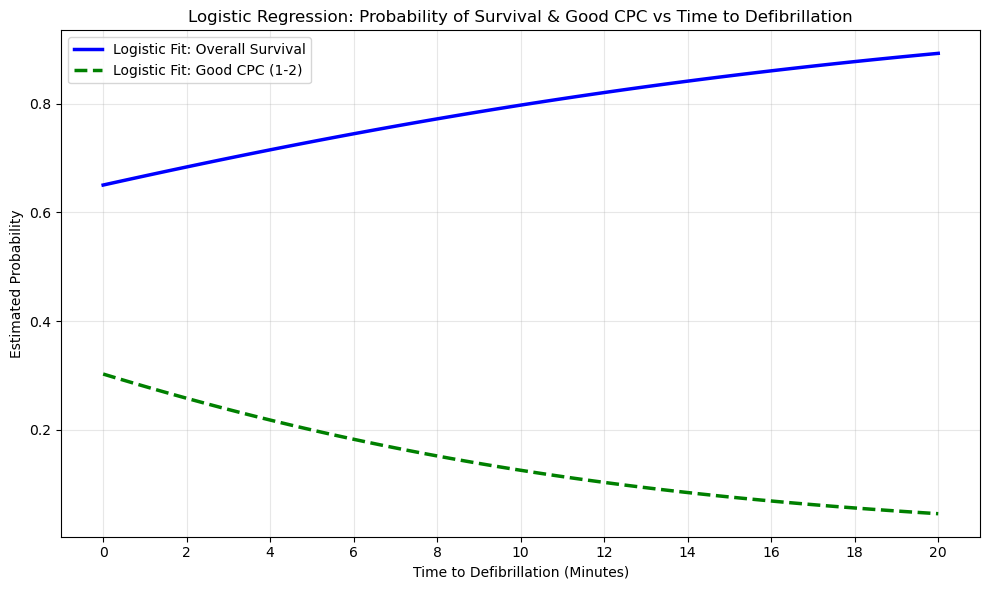

In [17]:
# 0-20 minutes used as the range
t_range = np.linspace(0, 20, 100)
X_pred = sm.add_constant(t_range)

# Predict probabilities across the 0-20 minute range for both models
y_pred_prob_surv = result.predict(X_pred)
y_pred_prob_cpc = result_cpc.predict(X_pred)

plt.figure(figsize=(10, 6))

# Plot the Logistic probability curve for Survival
plt.plot(t_range,
         y_pred_prob_surv,
         color='blue', 
         linewidth=2.5, 
         label='Logistic Fit: Overall Survival')

# Plot the Logistic probability curve for CPC
plt.plot(t_range, 
         y_pred_prob_cpc, 
         color='green', 
         linewidth=2.5, 
         linestyle='--', 
         label='Logistic Fit: Good CPC (1-2)')

plt.title('Logistic Regression: Probability of Survival & Good CPC vs Time to Defibrillation')
plt.xlabel('Time to Defibrillation (Minutes)')
plt.ylabel('Estimated Probability')
plt.xticks(np.arange(0, 21, 2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()